# Festigkeit von Geweben

Ein Textilunternehmen produziert Gewebe auf einer großen Anzahl von Webstühlen (*Looms*).

Ziel ist eine möglichst gleichmäßige Festigkeit des hergestellten Materials. Der Prozessingenieur vermutet, dass sich die Webstühle hinsichtlich der erzeugten Festigkeit unterscheiden.

Um dies zu untersuchen, werden zufällig vier Webstühle aus der Produktion ausgewählt. Von jedem Webstuhl werden vier Gewebeproben entnommen und auf ihre Festigkeit geprüft.

## Versuchsaufbau

- Faktor: Webstuhl (*Loom*)
- Antwortvariable: Festigkeit (*Strength*)
- Vier zufällig ausgewählte Webstühle
- Vier Gewebeproben pro Webstuhl
- Zufällige Versuchsdurchführung
- Webstuhl wird als **Random Effect** modelliert

## Datengrundlage

![title](../img/table3-18.png)

## Ziele der Analyse

- Random-Effects-Modell
- Varianzkomponenten
- Intraklassenkorrelation
- REML-Schätzung

# Dateneingabe

Die Daten bestehen aus vier zufällig ausgewählten Webstühlen und jeweils vier Festigkeitsmessungen pro Webstuhl.

Da die Webstühle zufällig aus einer großen Population ausgewählt wurden, handelt es sich um einen zufälligen Faktor.

In [1]:
import pandas as pd

df = pd.DataFrame({
    "Loom": [
        1,1,1,1,
        2,2,2,2,
        3,3,3,3,
        4,4,4,4
    ],
    "Strength": [
        98,97,99,96,
        91,90,93,92,
        96,95,97,95,
        95,96,99,98
    ]
})

df

,Loom,Strength
0,1,98
1,1,97
2,1,99
3,1,96
4,2,91
5,2,90
6,2,93
7,2,92
8,3,96
9,3,95


# Deskriptive Statistik

Zunächst betrachten wir Mittelwerte und Streuungen der einzelnen Webstühle.

Große Unterschiede zwischen den Mittelwerten können auf systematische Unterschiede zwischen den Webstühlen hinweisen.

In [2]:
df.groupby("Loom")["Strength"].agg(
    ["count", "mean", "std", "var"]
)

,count,mean,std,var
Loom,,,,
1,4,97.50,1.290994,1.666667
2,4,91.50,1.290994,1.666667
3,4,95.75,0.957427,0.916667
4,4,97.00,1.825742,3.333333


# Grafische Analyse

Ein Boxplot ermöglicht einen ersten Vergleich der Festigkeitswerte der einzelnen Webstühle.

Besonders interessant sind:

- Unterschiede zwischen den Mittelwerten
- Streuung innerhalb der Webstühle
- mögliche Ausreißer


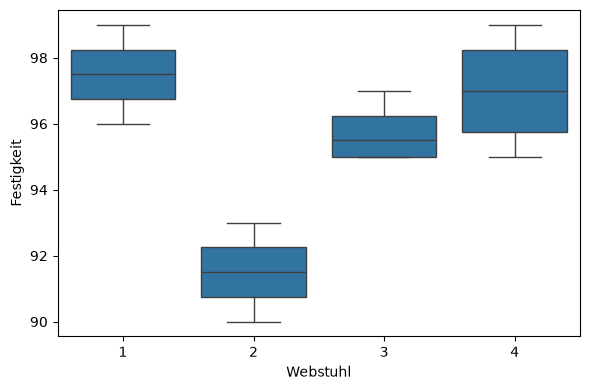

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="Loom",
    y="Strength"
)

plt.xlabel("Webstuhl")
plt.ylabel("Festigkeit")

plt.tight_layout()

plt.show()

# Random-Effects-Modell

Das Modell lautet

$
y_{ij}
=
\mu
+
\tau_i
+
\varepsilon_{ij}
$

wobei

$
\tau_i \sim N(0,\sigma_\tau^2)
$

zufällige Webstuhleffekte beschreibt.

Im Gegensatz zum Fixed-Effects-Modell interessieren wir uns nicht für die einzelnen Webstühle, sondern für die Variabilität in der gesamten Population von Webstühlen.

In [4]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

model = ols(
    "Strength ~ C(Loom)",
    data=df
).fit()

anova_table = anova_lm(
    model,
    typ=2
)

anova_table["MS"] = (
    anova_table["sum_sq"]
    / anova_table["df"]
)

anova_table.round(2)

,sum_sq,df,F,PR(>F),MS
C(Loom),89.19,3.0,15.68,0.0,29.73
Residual,22.75,12.0,NaN,NaN,1.90


# Schätzung der Varianzkomponenten

Die ANOVA liefert:

$
MS_{Treatments}
=
\sigma^2+n\sigma_\tau^2
$

$
MS_E
=
\sigma^2
$

Daraus ergeben sich Schätzungen für

- Fehlervarianz
- Varianz zwischen den Webstühlen

In [12]:
MST = anova_table.loc["C(Loom)", "MS"]
MSE = anova_table.loc["Residual", "MS"]

n = 4

sigma2_hat = MSE

sigma_tau2_hat = (
    MST - MSE
) / n

sigma_y2_hat = (
    sigma2_hat
    + sigma_tau2_hat
)

print(f"Fehlervarianz: {sigma2_hat:.2f}")
print(f"Webstuhlvarianz: {sigma_tau2_hat:.2f}")
print(f"Gesamtvarianz: {sigma_y2_hat:.2f}")

Fehlervarianz: 1.90
Webstuhlvarianz: 6.96
Gesamtvarianz: 8.85


# Anteil der Gesamtvariabilität

Ein wichtiger Kennwert ist der Anteil der Gesamtvariabilität, der auf Unterschiede zwischen den Webstühlen zurückzuführen ist.

Dies entspricht der Intraklassenkorrelation.

In [13]:
icc = (
    sigma_tau2_hat
    /
    sigma_y2_hat
)

print(
    f"Anteil der Variabilität "
    f"zwischen Webstühlen: "
    f"{100*icc:.1f}%"
)

Anteil der Variabilität zwischen Webstühlen: 78.6%


# REML-Schätzung

In modernen Statistikpaketen werden Varianzkomponenten meist mit der Methode der Residual Maximum Likelihood (REML) geschätzt.

Im Unterschied zur klassischen ANOVA-Schätzung liefert REML zusätzlich Konfidenzintervalle für die Varianzkomponenten.

In [9]:
from statsmodels.regression.mixed_linear_model import MixedLM

reml_model = MixedLM.from_formula(
    "Strength ~ 1",
    groups="Loom",
    data=df
)

reml_result = reml_model.fit()

print(reml_result.summary())

        Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Strength
No. Observations: 16      Method:             REML    
No. Groups:       4       Scale:              1.8958  
Min. group size:  4       Log-Likelihood:     -31.5965
Max. group size:  4       Converged:          Yes     
Mean group size:  4.0                                 
------------------------------------------------------
            Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------
Intercept   95.438    1.363 70.015 0.000 92.766 98.109
Loom Var     6.958    4.927                           



In [11]:
print("Residual variance:")
print(result.scale)

print("\nLoom variance:")
print(result.cov_re.iloc[0,0])

Residual variance:
1.8958364106145196

Loom variance:
6.958284308577714


# Interpretation

Die Analyse zeigt, dass die Festigkeit nicht nur innerhalb eines Webstuhls variiert.

Ein großer Teil der Variabilität wird durch Unterschiede zwischen den Webstühlen verursacht.

Die geschätzte Varianz zwischen den Webstühlen ist deutlich größer als die Fehlervarianz.

Für das Unternehmen bedeutet dies, dass Maßnahmen zur Vereinheitlichung der Webstühle das Potenzial haben, die Gesamtstreuung der Produktqualität erheblich zu reduzieren.